# AI Agent Bug-Fixing — **Matched (1:1) Version**

This is the fair, **equal-sized, repo-matched** version of the agent-vs-human comparisons.

**How the sample is built:** within each repository we keep an **equal number of agent and human** bug-fix PRs (the smaller of the two counts in that repo). So the agent and human groups have the **same size** and come from the **same repositories** — removing both the count imbalance and the repo-mix confound.

We re-run the comparisons that involve humans:
- M1 Acceptance · M2 Time-to-merge · M3 Patch size by file role · M4 Bug-type mix · M5 Reverts

*(The over-time / agent-only findings — metrics over time, agent switching, instruction files — don't involve a human baseline, so they're unchanged from `paper_findings.ipynb` and not repeated here.)*

In [1]:
import sys; sys.path.insert(0,'.')
from pathlib import Path
from analysis_utils import (
    load_fix_prs, load_commits, load_commit_details,
    merge_rate, chi_square, odds_ratio_ci, mann_whitney, cliffs_delta, sig_label,
    classify_file_role, classify_bug_type, BUG_CATEGORIES,
    set_plot_style, save_fig, AGENTS, AGENT_COLORS,
)
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
set_plot_style()
FIG = Path('results/matched_figures')
CATS = list(BUG_CATEGORIES) + ['other']

# ---- load + per-PR features (bug type, production lines, was-reverted) ----
df = load_fix_prs()
df['bug_type'] = df['title'].map(classify_bug_type)
commits = load_commits(); commits['message'] = commits['message'].fillna('')
details = load_commit_details(); details['role'] = details['filename'].map(classify_file_role)
prod = details[details.role=='prod'].groupby('pr_id')['additions'].sum()
df['prod_added'] = df['id'].map(prod)
rev = commits[commits.message.str.contains('reverts commit', case=False, na=False)]
reverted = set(s[:12] for s in rev.message.str.extract(r'reverts commit ([0-9a-f]{7,40})', flags=re.I)[0].dropna())
commits['sha12'] = commits['sha'].str[:12]
df['was_reverted'] = df['id'].isin(set(commits.loc[commits.sha12.isin(reverted),'pr_id']))

# ---- build the 1:1 repo-matched sample ----
def balanced_repo_sample(d, seed=0):
    parts=[]
    for _, g in d.groupby('repo'):
        a = g[g.is_agent & g.agent.isin(AGENTS)]
        h = g[~g.is_agent]
        n = min(len(a), len(h))
        if n:
            parts.append(a.sample(n, random_state=seed))
            parts.append(h.sample(n, random_state=seed))
    return pd.concat(parts).reset_index(drop=True)

bal = balanced_repo_sample(df)
bal_ag = bal[bal.is_agent]; bal_hu = bal[~bal.is_agent]
print(f'Matched sample: {len(bal_ag):,} agent  vs  {len(bal_hu):,} human  '
      f'(equal per repo, across {bal["repo"].nunique():,} shared repos)')

Loading fix PRs from HuggingFace ...


  AIDev repo coverage: 8,959 distinct repos
  Survivorship cutoff at 2026-01-29: dropped 33,123 recent PRs
  Fix PRs loaded: 371,577  |  Agent: 108,080  |  Human: 263,497


Loading commits from HuggingFace ...


  Commits loaded: 1,156,238
Loading commit details from HuggingFace ...


  Commit details loaded: 7,451,150


Matched sample: 34,216 agent  vs  34,216 human  (equal per repo, across 1,150 shared repos)


## M1 — Acceptance rate (equal-sized, repo-matched)

Agent  acceptance: 80.5%  (n=34,216)
Human  acceptance: 85.9%  (n=34,216)
OR (agent vs human) = 0.68 [0.65,0.70] ***

  Copilot       61.2%  (n=6,050)
  Cursor        89.2%  (n=15,424)
  Claude_Code   84.3%  (n=11,055)
  Devin         45.5%  (n=1,687)
  -> Saved: results\matched_figures\m1_acceptance_matched.png


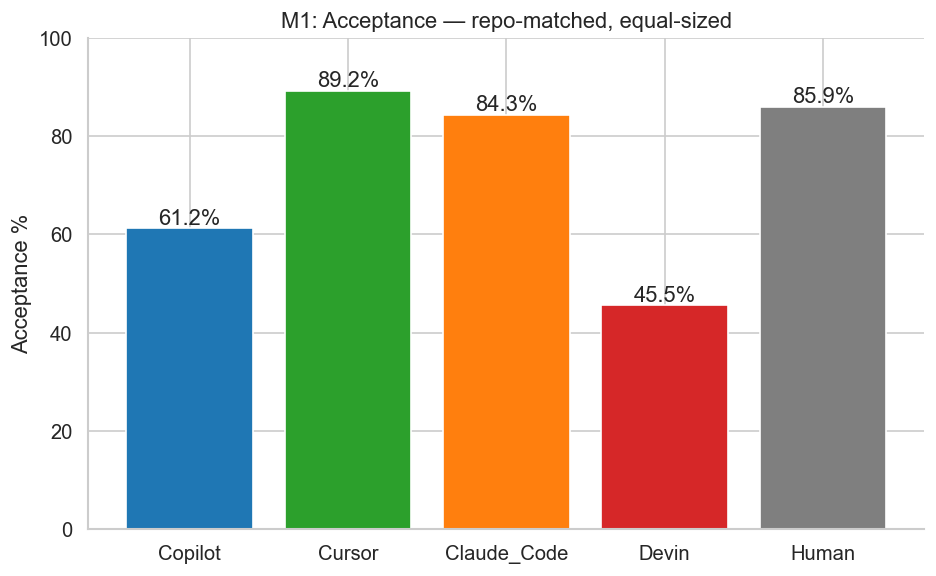

WindowsPath('results/matched_figures/m1_acceptance_matched.png')

In [2]:
am,at,ar = merge_rate(bal_ag); hm,ht,hr = merge_rate(bal_hu)
orr,lo,hi = odds_ratio_ci(am,at,hm,ht); _,p = chi_square(am,at,hm,ht)
print(f'Agent  acceptance: {ar:.1f}%  (n={at:,})')
print(f'Human  acceptance: {hr:.1f}%  (n={ht:,})')
print(f'OR (agent vs human) = {orr:.2f} [{lo:.2f},{hi:.2f}] {sig_label(p)}')
print()
groups=AGENTS+['Human']; rates=[]
for a in AGENTS:
    s=bal_ag[bal_ag.agent==a]; rates.append(s.is_merged.mean()*100)
    print(f'  {a:<12} {rates[-1]:5.1f}%  (n={len(s):,})')
rates.append(hr)
fig,ax=plt.subplots(figsize=(8,5))
ax.bar(groups,rates,color=[AGENT_COLORS[g] for g in groups])
for i,v in enumerate(rates): ax.text(i,v,f'{v:.1f}%',ha='center',va='bottom')
ax.set_ylim(0,100); ax.set_ylabel('Acceptance %'); ax.set_title('M1: Acceptance — repo-matched, equal-sized')
fig.tight_layout(); save_fig(fig,'m1_acceptance_matched',FIG,show=True)

**Answer:** matched and equal-sized, agents accept **slightly lower** than humans overall — **80.5% vs 85.9% (OR 0.68, p<0.001)**. Per agent: Cursor still **beats** humans (89%), Claude Code ~matches (84%), but **Copilot (61%) and Devin (46%) pull the pooled rate down**.

**How:** within each repo keep equal agent/human counts, then compute merged% per group and the agent-vs-human odds ratio.

**Caveat:** matched on repo only (not also time); the pooled OR mixes the agent composition.

## M2 — Time-to-merge (matched)

Median TTM — agent 1.92h vs human 4.42h  | Cliff delta=-0.14 (negligible)
  -> Saved: results\matched_figures\m2_ttm_matched.png


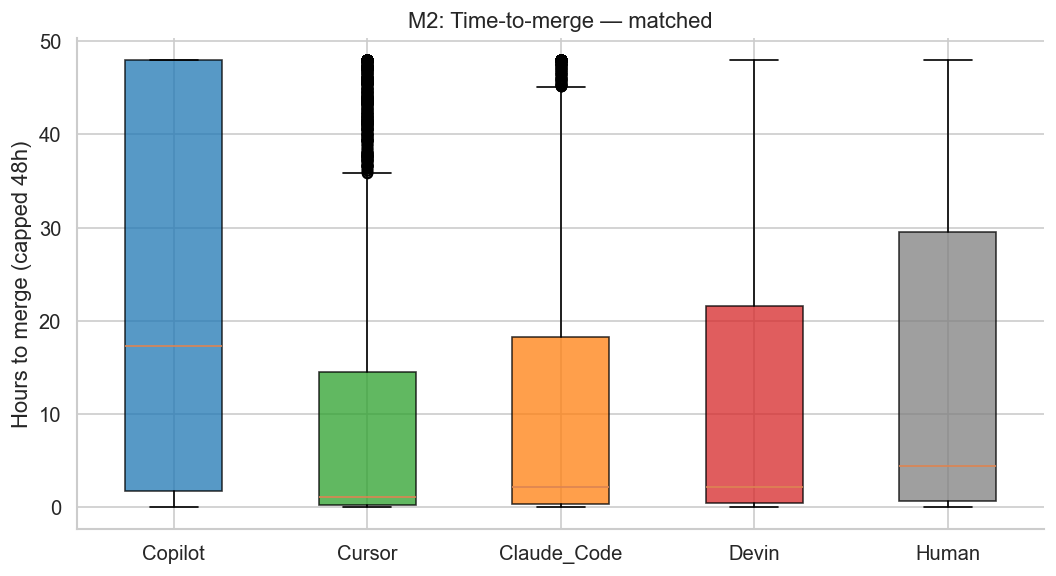

WindowsPath('results/matched_figures/m2_ttm_matched.png')

In [3]:
a_ttm=bal_ag[bal_ag.is_merged]['hours_to_merge']; h_ttm=bal_hu[bal_hu.is_merged]['hours_to_merge']
d,mag=cliffs_delta(a_ttm,h_ttm)
print(f'Median TTM — agent {a_ttm.median():.2f}h vs human {h_ttm.median():.2f}h  | Cliff delta={d:+.2f} ({mag})')
labels=AGENTS+['Human']; data=[bal_ag[(bal_ag.agent==a)&bal_ag.is_merged]['hours_to_merge'].clip(upper=48).dropna() for a in AGENTS]
data.append(h_ttm.clip(upper=48).dropna())
fig,ax=plt.subplots(figsize=(9,5))
bp=ax.boxplot(data,labels=labels,patch_artist=True)
for patch,l in zip(bp['boxes'],labels): patch.set_facecolor(AGENT_COLORS[l]); patch.set_alpha(0.75)
ax.set_ylabel('Hours to merge (capped 48h)'); ax.set_title('M2: Time-to-merge — matched')
fig.tight_layout(); save_fig(fig,'m2_ttm_matched',FIG,show=True)

**Answer:** the speed gap **shrinks sharply** once matched — agents median **1.92h vs 4.42h**, but the effect size is **negligible** (Cliff's δ = −0.14). The unmatched "~11× faster" was largely because agents cluster in fast-merging repos.

**How:** median open→merge hours for merged PRs in the matched sample; Cliff's delta for effect size.

**Caveat:** fast merges may include automated/CI merges (no auto-merge flag in the data).

## M3 — Patch size, production lines (matched)

Median production lines added (matched):
  Human        13
  Copilot      15
  Cursor       14
  Claude_Code  9
  Devin        23


  -> Saved: results\matched_figures\m3_patch_size_matched.png


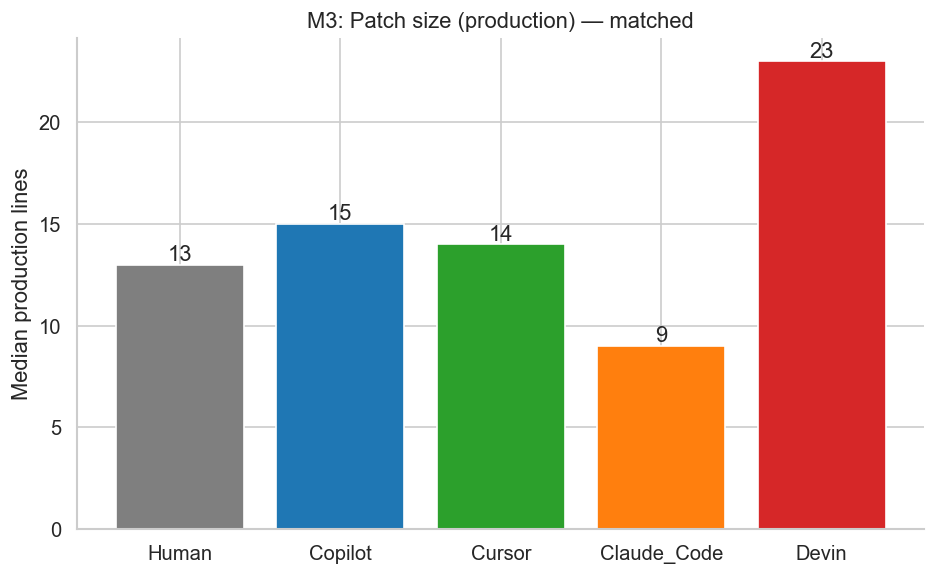

WindowsPath('results/matched_figures/m3_patch_size_matched.png')

In [4]:
print('Median production lines added (matched):')
rows=[('Human', bal_hu['prod_added'].median())]
for a in AGENTS: rows.append((a, bal_ag[bal_ag.agent==a]['prod_added'].median()))
for g,v in rows: print(f'  {g:<12} {v:.0f}')
fig,ax=plt.subplots(figsize=(8,5))
gs=[g for g,_ in rows]; vs=[v for _,v in rows]
ax.bar(gs,vs,color=[AGENT_COLORS[g] for g in gs])
for i,v in enumerate(vs): ax.text(i,v,f'{v:.0f}',ha='center',va='bottom')
ax.set_ylabel('Median production lines'); ax.set_title('M3: Patch size (production) — matched')
fig.tight_layout(); save_fig(fig,'m3_patch_size_matched',FIG,show=True)

**Answer:** matched, agent production patches are **about the same size as humans** (Copilot 15, Cursor 14 vs human 13) — **Claude Code smaller (9)**, Devin larger (23). The unmatched "agents write ~50% more" was mostly repo mix.

**How:** median production lines added per PR (files classified prod/test/generated by path) per group, on the matched sample.

**Caveat:** file role is a path-pattern heuristic.

## M4 — Bug-type mix (matched)

build/ci: agent 18.0% vs human 7.0%


  -> Saved: results\matched_figures\m4_bug_types_matched.png


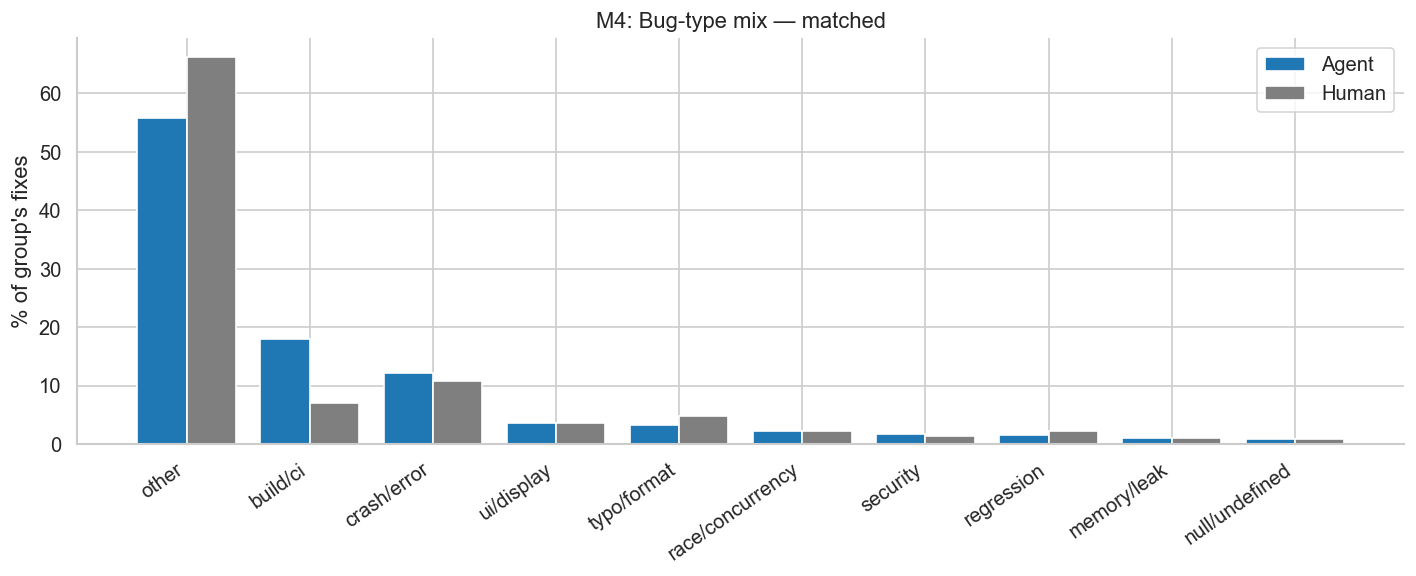

WindowsPath('results/matched_figures/m4_bug_types_matched.png')

In [5]:
a_sh=bal_ag.bug_type.value_counts(normalize=True).reindex(CATS).fillna(0)*100
h_sh=bal_hu.bug_type.value_counts(normalize=True).reindex(CATS).fillna(0)*100
order=a_sh.sort_values(ascending=False).index.tolist()
print(f'build/ci: agent {a_sh["build/ci"]:.1f}% vs human {h_sh["build/ci"]:.1f}%')
x=np.arange(len(order)); w=0.4
fig,ax=plt.subplots(figsize=(12,5))
ax.bar(x-w/2,a_sh[order].values,w,label='Agent',color='#1f77b4')
ax.bar(x+w/2,h_sh[order].values,w,label='Human',color='#7f7f7f')
ax.set_xticks(x); ax.set_xticklabels(order,rotation=35,ha='right'); ax.legend()
ax.set_ylabel("% of group's fixes"); ax.set_title('M4: Bug-type mix — matched')
fig.tight_layout(); save_fig(fig,'m4_bug_types_matched',FIG,show=True)

**Answer:** even on the same repos, agents still do **more build/CI/dependency fixes** than humans.
**How:** label each PR by title keywords; compare the % mix of agent vs human on the matched sample.
**Caveat:** title-keyword labels are coarse (~half 'other').

## M5 — Reverts (matched)

Revert rate (matched merged fixes): agent 0.34% vs human 0.51%


  -> Saved: results\matched_figures\m5_reverts_matched.png


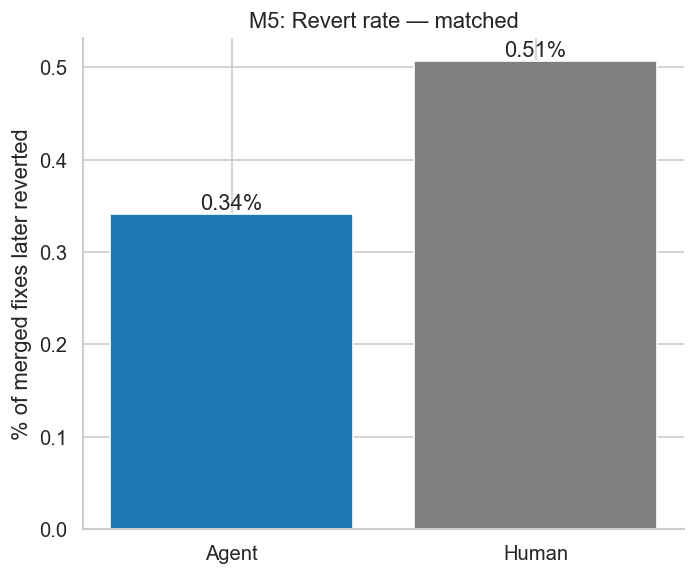

WindowsPath('results/matched_figures/m5_reverts_matched.png')

In [6]:
mag=bal_ag[bal_ag.is_merged]; mhu=bal_hu[bal_hu.is_merged]
print(f'Revert rate (matched merged fixes): agent {mag.was_reverted.mean()*100:.2f}% vs human {mhu.was_reverted.mean()*100:.2f}%')
fig,ax=plt.subplots(figsize=(6,5))
vals=[mag.was_reverted.mean()*100, mhu.was_reverted.mean()*100]
ax.bar(['Agent','Human'],vals,color=['#1f77b4','#7f7f7f'])
for i,v in enumerate(vals): ax.text(i,v,f'{v:.2f}%',ha='center',va='bottom')
ax.set_ylabel('% of merged fixes later reverted'); ax.set_title('M5: Revert rate — matched')
fig.tight_layout(); save_fig(fig,'m5_reverts_matched',FIG,show=True)

**Answer (preliminary):** matched, agent fixes are still **reverted less** than human fixes.
**How:** % of merged fixes whose commit later appears in a "This reverts commit <sha>" message, agent vs human on the matched sample.
**Caveat:** reverts are rare and only visible inside fix PRs; agent PRs are also newer on average.

## Summary — what survives proper matching

The equal-sized, repo-matched comparison is humbling: several "agent advantages" from the raw data **shrink or reverse** once you compare like with like.

**Eroded by matching (were repo-mix artifacts):**
- **Acceptance** — agents end up **slightly below** humans (80.5% vs 85.9%); Cursor still beats humans, Copilot/Devin lag.
- **Speed** — the huge advantage collapses to a **negligible** effect (1.92h vs 4.42h).
- **Patch size** — agents are **about the same** as humans (Claude Code smaller).

**Still hold after matching (the durable, bug-fix-specific findings):**
- Agents fix **more build/CI/dependency bugs** (18% vs 7%).
- Agent fixes are **reverted less** (0.34% vs 0.51%, preliminary).

**Takeaway:** most headline "agent vs human" gaps are repo-mix artifacts. The robust, bug-fix-specific differences are *what kind of bug* agents fix, and (tentatively) *how durable* their fixes are.